# 13 Visualization with HoloViews Explorer

Visualization is an inspection surface: use it to check that TAL transformations preserved the intended semantics.


## Imports

Imports are kept separate so the instructional cells can focus on TAL semantics.


In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import xarray as xr
from IPython.display import display

import tal
from tal.core.component_ops import ComponentRegistryOptions, ComponentSpec
from tal.core.group_ops import GroupingFoundationOptions
from tal.viz import AOVizOptions

try:
    import holoviews as hv  # noqa: F401
    import hvplot.xarray  # noqa: F401
    import panel as pn
    # import holoviews as hv
    # import hvplot.xarray  # noqa

    HAS_VIZ = True
except ImportError as exc:
    HAS_VIZ = False
    VIZ_IMPORT_ERROR = exc

if HAS_VIZ:
    pn.extension()
    hv.extension("bokeh")
    print("HoloViews/hvPlot available.")
else:
    print("Visualization dependencies missing:", VIZ_IMPORT_ERROR)

from pathlib import Path
import sys

_release_dir = Path.cwd()
if not (_release_dir / '_helpers.py').exists():
    candidate = Path.cwd() / 'examples' / 'release'
    if candidate.exists():
        _release_dir = candidate
if str(_release_dir) not in sys.path:
    sys.path.append(str(_release_dir))

from _helpers import (
    build_framegraph_spatial_payloads,
    build_topology_edge_payloads,
    compact_dataset,
    display_result,
    explain_expected_failure,
    make_imu_gps_alignment_aos,
    make_kinematics_demo_objects,
    make_pose_demo_objects,
    show_ao,
    summarize_ao,
)


HoloViews/hvPlot available.


## Outline and dependency note

This notebook uses optional `tal[viz]` dependencies. It focuses on which dimensions become x axes, overlays, groups, and components.


In [2]:
signal = np.asarray(
    [[1.0, 2.0, 3.0], [10.0, 11.0, 12.0]],
    dtype=float,
)

base_ds = xr.Dataset(
    data_vars={
        "signal": (("trial", "time"), signal),
        "other": (("trial", "time"), signal + 100.0),
    },
    coords={
        "trial": ("trial", np.asarray([0, 1], dtype=np.int64)),
        "time": ("time", np.asarray([0.0, 1.0, 2.0], dtype=float)),
        "t": ("time", np.asarray([0.1, 1.1, 2.1], dtype=float)),
        "size": ("trial", np.asarray([2, 3], dtype=np.int64)),
    },
)

ao = tal.AnalysisObject.from_data(
    base_ds,
    sequence_dim="time",
    batch_dims=("trial",),
    core_dims=(),
    param_coord="t",
    sequence_size_coord="size",
    validate=True,
)

xyz_values = np.arange(18, dtype=float).reshape(2, 3, 3)
component_ds = xr.Dataset(
    data_vars={"signal": (("trial", "time", "xyz"), xyz_values)},
    coords={
        "trial": ("trial", np.asarray([0, 1], dtype=np.int64)),
        "time": ("time", np.asarray([0.0, 1.0, 2.0], dtype=float)),
        "xyz": ("xyz", np.asarray(["x", "y", "z"], dtype=object)),
        "size": ("trial", np.asarray([3, 3], dtype=np.int64)),
    },
)

ao_component = tal.AnalysisObject.from_data(
    component_ds,
    sequence_dim="time",
    batch_dims=("trial",),
    core_dims=("xyz",),
    sequence_size_coord="size",
    validate=True,
)

ao_component = ao_component.components.define(
    opts=ComponentRegistryOptions(
        registry={"xyz": ComponentSpec(core_dim="xyz", labels=("x", "y", "z"))},
        replace=True,
    ),
    validate=True,
)

ao, ao_component


(<tal.core.analysis_object.AnalysisObject at 0x12712d400>,
 <tal.core.analysis_object.AnalysisObject at 0x12715d810>)

Before using `ao.viz`, a plain Matplotlib checkpoint keeps the data shape and validity easy to see.

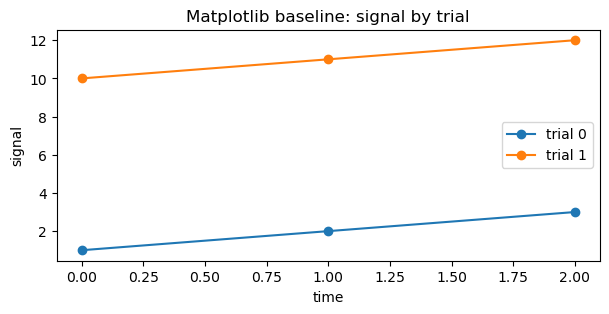

In [3]:
fig, ax = plt.subplots(figsize=(7, 3))
for trial in ao.unsafe_data['trial'].to_numpy():
    series = ao.unsafe_data['signal'].sel(trial=trial)
    ax.plot(ao.unsafe_data['time'], series, marker='o', label=f'trial {trial}')
ax.set(title='Matplotlib baseline: signal by trial', xlabel='time', ylabel='signal')
ax.legend(loc='best')


## Build demo AnalysisObjects

One AO is scalar over `(trial, time)`. Another has an `xyz` core dimension registered as a named component.


In [4]:
if not HAS_VIZ:
    raise RuntimeError("Install tal[viz] to run plotting cells.")

plot_line_default = ao.viz.line(opts=AOVizOptions(var="signal"))
plot_line_explicit_x = ao.viz.line(opts=AOVizOptions(var="signal", x="time", by=("trial",)))
plot_scatter = ao.viz.scatter(
    opts=AOVizOptions(var="signal", x="t", by=("trial",), kwargs={"alpha": 0.7})
)

display_result(
    'created ao.viz line/scatter objects',
    pd.DataFrame(
        [
            {'plot': 'line default', 'type': type(plot_line_default).__name__},
            {'plot': 'line explicit x/by', 'type': type(plot_line_explicit_x).__name__},
            {'plot': 'scatter', 'type': type(plot_scatter).__name__},
        ]
    ),
)
display(plot_line_default)


#### created ao.viz line/scatter objects

,plot,type
0,line default,DynamicMap
1,line explicit x/by,NdOverlay
2,scatter,NdOverlay


:DynamicMap   [trial]
   :Curve   [t]   (signal)

## Line and scatter plots

The plotting options make variable, x coordinate, and overlay dimensions explicit.


In [5]:
plot_explorer_default = ao.viz.explorer(
    opts=AOVizOptions(
        var='signal',
        x='time',
        by=('trial',),
        kwargs={'kind': 'line'},
    )
)

plot_group_key_trial = ao.viz.line(
    opts=AOVizOptions(var='signal', group_key='trial')
)

external_group_key = xr.DataArray(
    np.asarray([[1.0, 2.0, np.nan], [1.0, 2.0, 3.0]], dtype=float),
    dims=('trial', 'time'),
    coords={
        'trial': ao.unsafe_data.coords['trial'],
        'time': ao.unsafe_data.coords['time'],
    },
)

plot_group_key_external = ao.viz.line(
    opts=AOVizOptions(
        var='signal',
        group_key=external_group_key,
        group_foundation_opts=GroupingFoundationOptions(na_key_policy='group'),
    )
)

display_result(
    'Explorer and grouping objects',
    pd.DataFrame(
        [
            {'plot': 'ao.viz.explorer(var="signal", x="time", by=("trial",), kind="line")', 'type': type(plot_explorer_default).__name__},
            {'plot': 'group_key trial', 'type': type(plot_group_key_trial).__name__},
            {'plot': 'external group_key', 'type': type(plot_group_key_external).__name__},
        ]
    ),
)
display(plot_explorer_default)


#### Explorer and grouping objects

,plot,type
0,"ao.viz.explorer(var=""signal"", x=""time"", by=(""t...",hvGridExplorer
1,group_key trial,NdOverlay
2,external group_key,NdOverlay


hvGridExplorer(advanced=Advanced(explorer=..., name='Advanced00449', opts={}), axes=Axes(explorer=..., height=None, legend='bottom_right', logx=False, logy=False, name='Axes00443', responsive=True, shared_axes=True, width=None, xlim=None, ylim=None), by=['trial'], code="da.hvplot(\n    by=['trial'],\n    kind='line',\n    x='time',\n    legend='bottom_right',\n    widget_location='bottom',\n)", colormapping=Colormapping(clim=None, cmap='kbc_r', cnorm='linear', color=None, colorbar=None, explorer=..., name='Colormapping00444', rescale_discrete_levels=True, symmetric=False), geographic=Geographic(crs=None, crs_kwargs={}, explorer=..., feature_scale='110m', features=None, geo=False, global_extent=None, name='Geographic00446', project=False, projection=None, projection_kwargs={}, tiles=None), groupby=[], kind='line', labels=Labels(clabel='', explorer=..., fontscale=1, name='Labels00445', rot=0, title='', xlabel='', ylabel=''), name='hvGridExplorer00421', operations=Operations(aggregator=None, datashade=False, dynspread=False, explorer=..., name='Operations00447', rasterize=False, x_sampling=None, y_sampling=None), statusbar=StatusBar(live_update=True, name='StatusBar00436'), style=Style(alpha=1, explorer=..., name='Style00448'), x='time', y='time', y_multi=[])

## Explorer mode and grouping

The default explorer view below is configured as a scalar trajectory line plot: `x="t"` uses the param coordinate, `var="signal"` supplies y values, and `by=("trial",)` overlays the batch dimension. `group_key` is shown separately as a way to drive grouping from a coordinate or external key.

In [6]:
plot_component_default = ao_component.viz.component("xyz", kind="line")
plot_component_grouped = ao_component.viz.component(
    "xyz",
    kind="line",
    opts=AOVizOptions(max_overlay_items=2),
)
plot_component_override = ao_component.viz.component(
    "xyz",
    kind="line",
    opts=AOVizOptions(by=("trial",)),
)

display(
    pd.DataFrame(
        [
            {'plot': 'component default', 'type': type(plot_component_default).__name__},
            {'plot': 'component grouped', 'type': type(plot_component_grouped).__name__},
            {'plot': 'component override', 'type': type(plot_component_override).__name__},
        ]
    )
)
display(plot_component_default)


,plot,type
0,component default,DynamicMap
1,component grouped,DynamicMap
2,component override,DynamicMap


:DynamicMap   [trial]
   :NdOverlay   [xyz]
      :Curve   [time]   (signal)

## Managing browser overhead

Interactive plots embed data in notebooks; use overlay limits and focused selections for large datasets.


In [7]:
from tal.viz import component as viz_component
from tal.viz import explorer as viz_explorer
from tal.viz import line as viz_line

plot_functional_line = viz_line(ao, opts=AOVizOptions(var="signal", x="t"))
plot_functional_explorer = viz_explorer(ao)

display_result(
    'Functional viz API objects',
    pd.DataFrame(
        [
            {'plot': 'viz_line(...)', 'type': type(plot_functional_line).__name__},
            {'plot': 'viz_explorer(...)', 'type': type(plot_functional_explorer).__name__},
        ]
    ),
)
display(plot_functional_line)


#### Functional viz API objects

,plot,type
0,viz_line(...),DynamicMap
1,viz_explorer(...),hvGridExplorer


:DynamicMap   [trial]
   :Curve   [t]   (signal)

## Component plotting

Component plotting first extracts a registered component, then dispatches to the same visualization surface.


## Functional API parity

The functional API mirrors accessor methods and is useful when accessor style is inconvenient.


## Choosing a plotting approach

| Need | API |
|---|---|
| trajectory curve | `ao.viz.line` |
| point cloud/check samples | `ao.viz.scatter` |
| interactive exploration | `ao.viz.explorer` |
| registered payload component | `ao.viz.component` |

**Exercise:** change `x`, `by`, and `max_overlay_items` and inspect the resulting plot.
